<a href="https://colab.research.google.com/github/LUCASCAZANE/Proj1_Form_Cont_Caixa_Verso/blob/Proj1_Form_Cont_Caixa_Verso/projeto1_formacao_continuada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Pacote para criar marca d'agua imprimindo assim as versões dos pacotes
!pip install -q -U watermark

In [2]:
# Pacote para visualizar valores ausentes em uma variável
!pip install -q missingno

In [3]:
# Imports
# Primeira dupla para manipulação de dados
import pandas as pd
import numpy as np

# A Segunda dupla para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pacote para criar visualização dos valores ausentes
import missingno as msno

In [4]:
# Carregando o DF
df_FG_Sebrae = pd.read_csv("Op_Garantia_FG_BNDES_Sebrae.csv", sep=';')

In [5]:
# Visualizando as 10 primeiras linhas do df
df_FG_Sebrae.head(10)

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
0,BTG PACTUAL,**.*45.846/0001-**,M.A. COMERCIO DIGITAL LTDA,Micro,"97722,01","78177,61","97722,01",2026-04-14,MIRASSOL,SP,MIRASSOL,SP
1,BTG PACTUAL,**.*87.844/0001-**,SEA TEXTIL LTDA,Pequena,"117266,41","93813,13","117266,41",2026-04-14,INDAIAL,SC,INDAIAL,SC
2,BTG PACTUAL,**.*04.711/0001-**,M J LTDA,Micro,"14999,61","11999,69","14999,61",2026-04-14,FRANCISCO MORATO,SP,FRANCISCO MORATO,SP
3,BTG PACTUAL,**.*07.697/0001-**,POUSADA VILLA BILAC LTDA,Micro,"17262,08","13809,66","17262,08",2026-04-14,BLUMENAU,SC,BLUMENAU,SC
4,BTG PACTUAL,**.*16.091/0001-**,PATRICIA PET SHOP LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-15,CURITIBA,PR,CURITIBA,PR
5,BTG PACTUAL,**.*67.891/0001-**,JONATHAN OLIVEIRA CONSULTORIA IMOBILIARIA LTDA,Micro,"11716,88","9373,5","11716,88",2026-04-15,SAO PAULO,SP,SAO PAULO,SP
6,BTG PACTUAL,**.*40.853/0001-**,GOIVA ARQUITETURA LTDA,Pequena,"42962,22","34369,78","42962,22",2026-04-15,SAO PAULO,SP,SAO PAULO,SP
7,BTG PACTUAL,**.*69.176/0001-**,J. P. CONSTRUCOES LTDA,Pequena,"26624,2","21299,36","26624,2",2026-04-15,CUIABA,MT,CUIABA,MT
8,BTG PACTUAL,**.*15.757/0001-**,PAPILIO GIFTS COMERCIO LTDA,Micro,"8592,64","6874,11","8592,64",2026-04-16,CURITIBA,PR,CURITIBA,PR
9,BTG PACTUAL,**.*47.568/0001-**,SILVIO FELIX MEDEIROS FILHO LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-16,PASSO FUNDO,RS,PASSO FUNDO,RS


In [6]:
# Numero (linhas e colunas)
df_FG_Sebrae.shape

(19302, 12)

In [7]:
# Informações
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nome_agente_financeiro      19302 non-null  str  
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str  
 2   nome_cliente                19302 non-null  str  
 3   porte_cliente               19070 non-null  str  
 4   valor_credito               19302 non-null  str  
 5   valor_garantido             19302 non-null  str  
 6   valor_desembolsado          19302 non-null  str  
 7   data_solicitacao_outorga    19302 non-null  str  
 8   municipio_investimento      19302 non-null  str  
 9   uf_investimento             19302 non-null  str  
 10  municipio_sede_cliente      19302 non-null  str  
 11  uf_sede_cliente             19302 non-null  str  
dtypes: str(12)
memory usage: 1.8 MB


In [8]:
# Descrevendo os dados não numéricos
df_FG_Sebrae.describe(include = object)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19976\2392548830.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_FG_Sebrae.describe(include = object)


,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
count,19302,19302,19302,19070,19302,19302,19302,19302,19302,19302,19302,19302
unique,5,16529,18092,2,4751,4750,2876,105,2726,27,2726,27
top,BRADESCO,**.*10.837/0001-**,LTDA,Pequena,"103993,34","83194,67","100000,0",2025-09-17,SAO PAULO,SP,SAO PAULO,SP
freq,18873,5,7,18232,459,459,934,2095,1605,5154,1605,5154


## Algumas informações que podemos aferir até aqui:
### 1.   Existem 5 nomes distintios de Agente Financeiro.
### 2.   Existem CPF/CNPJ duplicados (Pode ser que tenham mais de uma operação).
### 3.   Pequena Empresa é o porte com maior frequencia na Base de Dados.
### 4.   Valor de Credito que mais possui na BD é R$ 103.993,34 com 4751 registros (Pode ser o limite de credito para algum determinado segmento).
### 5.   O municipio do investimento/sede_cliente que mais possui registros é SÃO PAULO com 2726.

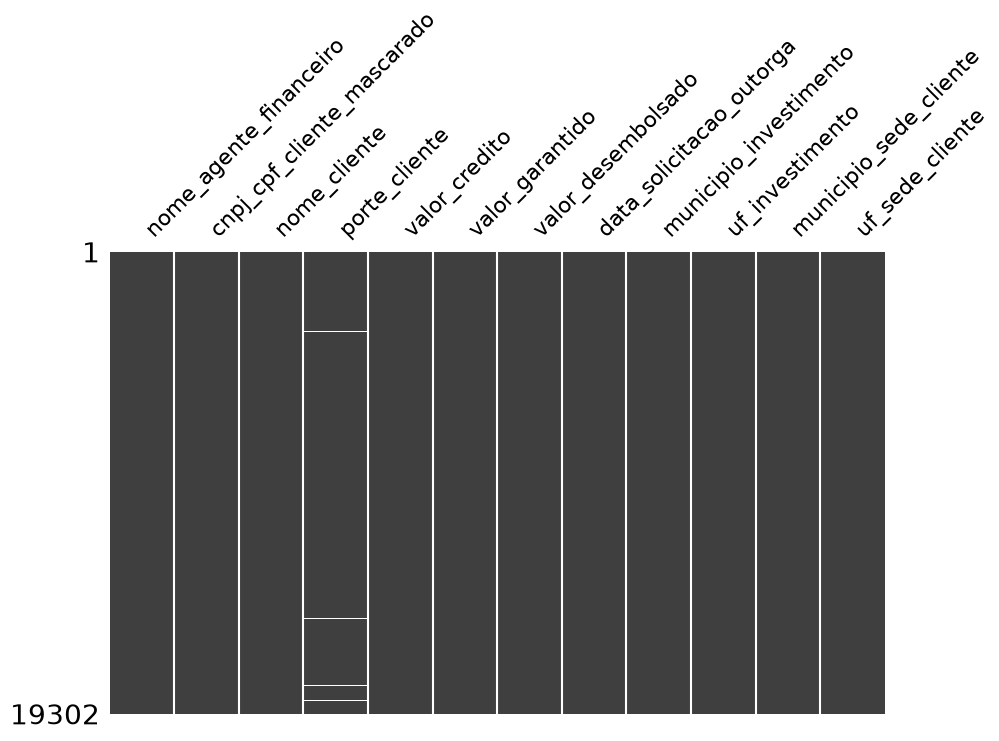

In [9]:
# Mapa de valores ausentes
msno.matrix(df_FG_Sebrae, figsize = (10, 6), sparkline = False)
plt.show()

In [10]:
# Usamos o método isna() para verificar valores ausentes em cada coluna
valores_ausentes = df_FG_Sebrae.isna().sum()
print("Valores ausentes por coluna:\n", valores_ausentes)

Valores ausentes por coluna:
 nome_agente_financeiro          0
cnpj_cpf_cliente_mascarado      0
nome_cliente                    0
porte_cliente                 232
valor_credito                   0
valor_garantido                 0
valor_desembolsado              0
data_solicitacao_outorga        0
municipio_investimento          0
uf_investimento                 0
municipio_sede_cliente          0
uf_sede_cliente                 0
dtype: int64


## Identificado 232 registros ausentes na variável 'porte_cliente'

In [11]:
# Investigando os tipos de dados das colunas do DataFrame
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nome_agente_financeiro      19302 non-null  str  
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str  
 2   nome_cliente                19302 non-null  str  
 3   porte_cliente               19070 non-null  str  
 4   valor_credito               19302 non-null  str  
 5   valor_garantido             19302 non-null  str  
 6   valor_desembolsado          19302 non-null  str  
 7   data_solicitacao_outorga    19302 non-null  str  
 8   municipio_investimento      19302 non-null  str  
 9   uf_investimento             19302 non-null  str  
 10  municipio_sede_cliente      19302 non-null  str  
 11  uf_sede_cliente             19302 non-null  str  
dtypes: str(12)
memory usage: 1.8 MB


### Como o percentual de Nan é baixo. Onde representa apenas (1,2%) da base toda optamos pela exclusão desses registros tendo em vista que nossa análise ira permear o estudo do porte da empresa e também porque não teremos como confirmar essa informação com a área de negocio.

In [12]:
import os


# Tenta carregar na pasta raiz ou na pasta dados
if os.path.exists("Op_Garantia_FG_BNDES_Sebrae.csv"):
    caminho = "Op_Garantia_FG_BNDES_Sebrae.csv"
elif os.path.exists("../Op_Garantia_FG_BNDES_Sebrae.csv"):
    caminho = "../Op_Garantia_FG_BNDES_Sebrae.csv"
else:
    caminho = "../dados/Op_Garantia_FG_BNDES_Sebrae.csv"

# 1. Carrega dados
df_raw = pd.read_csv(caminho, sep=";", encoding="latin1")

# 2. Trata nulos da coluna porte_cliente
df_FG_Sebrae = df_raw.dropna(subset=["porte_cliente"]).copy()

# 3. Ajusta os tipos de dados
df_FG_Sebrae["porte_cliente"] = df_FG_Sebrae["porte_cliente"].astype("category")
df_FG_Sebrae["uf_investimento"] = df_FG_Sebrae["uf_investimento"].astype(
    "category"
)
df_FG_Sebrae["uf_sede_cliente"] = df_FG_Sebrae["uf_sede_cliente"].astype(
    "category"
)
df_FG_Sebrae["data_solicitacao_outorga"] = pd.to_datetime(
    df_FG_Sebrae["data_solicitacao_outorga"]
)

print(
    f"Tratamento concluído! Restaram {len(df_FG_Sebrae)} linhas sem nulos no porte."
)

Tratamento concluído! Restaram 19070 linhas sem nulos no porte.


In [13]:

# VALIDACAO DE REGISTROS NULOS / FALTANTES
# ---------------------------------------------------------

# 1. Checagem focada na coluna principal tratada
nulos_porte = df_FG_Sebrae["porte_cliente"].isna().sum()
print(f"Valores nulos na coluna 'porte_cliente': {nulos_porte}")

# 2. Checagem geral de todas as colunas da base
linhas_com_faltantes = df_FG_Sebrae.isna().any(axis=1).sum()
linhas_completas = df_FG_Sebrae.notna().all(axis=1).sum()
total_linhas = len(df_FG_Sebrae)

print(f"Linhas com algum dado faltante : {linhas_com_faltantes}")
print(f"Linhas 100% completas           : {linhas_completas} de {total_linhas}")

# 3. Relatório geral de nulos por coluna
print("\n--- Detalhamento por Coluna ---")
print(df_FG_Sebrae.isna().sum())

Valores nulos na coluna 'porte_cliente': 0
Linhas com algum dado faltante : 0
Linhas 100% completas           : 19070 de 19070

--- Detalhamento por Coluna ---
nome_agente_financeiro        0
cnpj_cpf_cliente_mascarado    0
nome_cliente                  0
porte_cliente                 0
valor_credito                 0
valor_garantido               0
valor_desembolsado            0
data_solicitacao_outorga      0
municipio_investimento        0
uf_investimento               0
municipio_sede_cliente        0
uf_sede_cliente               0
dtype: int64


In [14]:
# ---------------------------------------------------------
# CHECAGEM DE LINHAS DUPLICADAS
# ---------------------------------------------------------

total_duplicadas = df_FG_Sebrae.duplicated().sum()
print(f"Linhas totalmente duplicadas: {total_duplicadas}")

# Caso existam duplicatas, exibe as primeiras para inspeção visual
if total_duplicadas > 0:
    duplicadas_df = df_FG_Sebrae[df_FG_Sebrae.duplicated(keep=False)].sort_values(
        "nome_cliente"
    )
    display(duplicadas_df.head(6))
else:
    print("Nenhum registro duplicado encontrado na base.")

Linhas totalmente duplicadas: 17


,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
15737,BRADESCO,**.*60.703/0001-**,ATLANTIDA INSPECAO VEICULAR LTDA.,Pequena,"114392,68","91514,14","110000,0",2025-07-01,CUBATAO,SP,CUBATAO,SP
9317,BRADESCO,**.*60.703/0001-**,ATLANTIDA INSPECAO VEICULAR LTDA.,Pequena,"114392,68","91514,14","110000,0",2025-07-01,CUBATAO,SP,CUBATAO,SP
179,BRADESCO,**.*07.176/0001-**,ATUAL MANUTENCOES TECNICAS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,SAO PAULO,SP,SAO PAULO,SP
9168,BRADESCO,**.*07.176/0001-**,ATUAL MANUTENCOES TECNICAS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,SAO PAULO,SP,SAO PAULO,SP
5808,BRADESCO,**.*39.616/0001-**,COSTA & LIMA SERVICOS GRAFICOS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,BELEM,PA,BELEM,PA
9090,BRADESCO,**.*39.616/0001-**,COSTA & LIMA SERVICOS GRAFICOS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,BELEM,PA,BELEM,PA


In [15]:
# Remove duplicatas
df_FG_Sebrae = df_FG_Sebrae.drop_duplicates().copy()
print(f"Base mantida com {len(df_FG_Sebrae)} registros únicos.")

Base mantida com 19053 registros únicos.


## Como a quantidade de duplicatas é so de 17 registros, optamos pela sua exclusão.

In [16]:
# ---------------------------------------------------------
# IDENTIFICAÇÃO DE OUTLIERS POR PORTE_CLIENTE VIA GROUPBY
# ---------------------------------------------------------

# 1. Força a conversão da coluna 'valor_credito' para float
if not pd.api.types.is_numeric_dtype(df_FG_Sebrae["valor_credito"]):
    df_FG_Sebrae["valor_credito"] = (
        df_FG_Sebrae["valor_credito"]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df_FG_Sebrae["valor_credito"] = pd.to_numeric(
        df_FG_Sebrae["valor_credito"], errors="coerce"
    )

# 2. Calculando Q1, Q3 e IQR agrupados por porte_cliente
q1 = df_FG_Sebrae.groupby("porte_cliente", observed=False)[
    "valor_credito"
].transform(lambda x: x.quantile(0.25))
q3 = df_FG_Sebrae.groupby("porte_cliente", observed=False)[
    "valor_credito"
].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

# 3. Definindo limites e flag de outlier
limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

df_FG_Sebrae["outlier_credito"] = (
    df_FG_Sebrae["valor_credito"] < limite_inferior
) | (df_FG_Sebrae["valor_credito"] > limite_superior)

# 4. Resumo quantitativo por porte de cliente
resumo_outliers = (
    df_FG_Sebrae.groupby("porte_cliente", observed=False)
    .agg(
        total_registros=("valor_credito", "count"),
        outliers_detectados=("outlier_credito", "sum"),
        media_credito=("valor_credito", "mean"),
    )
    .assign(
        pct_outliers=lambda x: (
            x["outliers_detectados"] / x["total_registros"]
        )
        * 100
    )
)

print("--- Resumo de Outliers por Porte de Cliente ---")
display(resumo_outliers.round(2))

print(
    f"\nTotal geral de outliers de crédito na base: {df_FG_Sebrae['outlier_credito'].sum()} ({df_FG_Sebrae['outlier_credito'].mean()*100:.2f}%)"
)

--- Resumo de Outliers por Porte de Cliente ---


,total_registros,outliers_detectados,media_credito,pct_outliers
porte_cliente,,,,
Micro,838,60,96368.24,7.16
Pequena,18215,178,208291.46,0.98



Total geral de outliers de crédito na base: 238 (1.25%)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_19976\3339781109.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


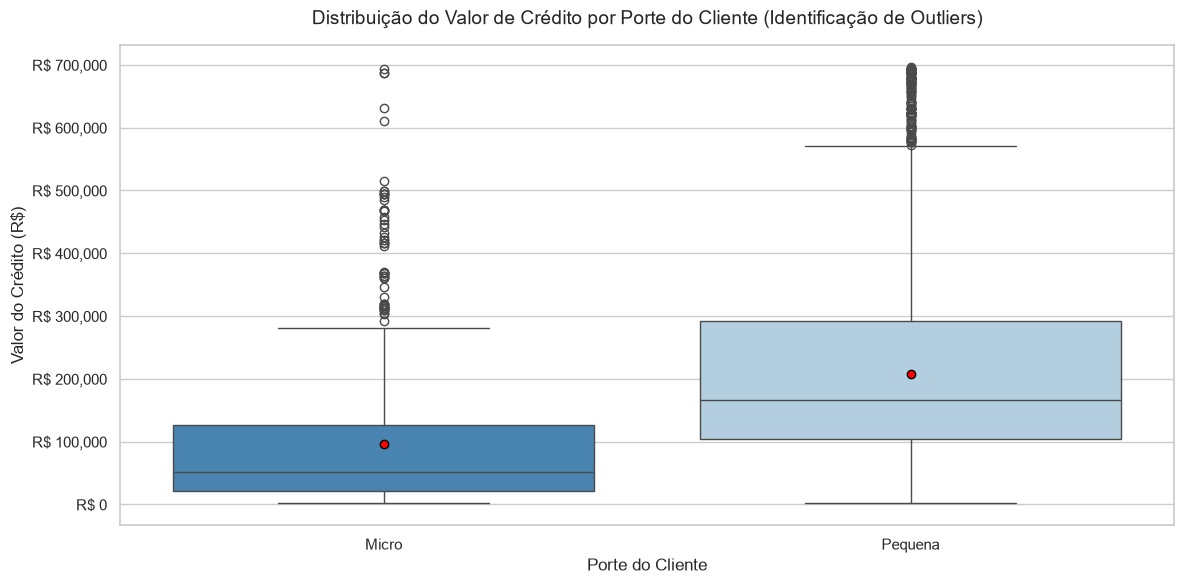

In [17]:
# Configuração visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Criação do Boxplot
ax = sns.boxplot(
    data=df_FG_Sebrae,
    x="porte_cliente",
    y="valor_credito",
    palette="Blues_r",
    showmeans=True,  # Exibe o ponto da média além da mediana
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
    },
)

# Títulos e rótulos
plt.title(
    "Distribuição do Valor de Crédito por Porte do Cliente (Identificação de Outliers)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Porte do Cliente", fontsize=12)
plt.ylabel("Valor do Crédito (R$)", fontsize=12)

# Formatação dos valores do Eixo Y em Reais (R$)
ax.yaxis.set_major_formatter("R$ {x:,.0f}")

# Exibir gráfico
plt.tight_layout()
plt.show()

In [18]:
# ---------------------------------------------------------
# RELATÓRIO DE TRATAMENTO E QUALIDADE DOS DADOS
# ---------------------------------------------------------

relatorio_tratamento = pd.DataFrame(
    [
        (
            "Registros com porte_cliente nulo",
            "Remoção com dropna()",
            int(df_raw["porte_cliente"].isna().sum()),
        ),
        (
            "Tipagem e padronização (porte_cliente e UFs)",
            "Conversão para category",
            3,  # porte_cliente, uf_investimento, uf_sede_cliente
        ),
        (
            "Tipagem de datas (data_solicitacao_outorga)",
            "Conversão com to_datetime()",
            1,
        ),
        (
            "Tipagem de valores financeiros (valor_credito)",
            "Tratamento de texto e conversão para float",
            1,
        ),
        (
            "Linhas totalmente duplicadas na base",
            "Identificação / remoção com drop_duplicates()",
            int(total_duplicadas),
        ),
        (
            "Métricas financeiras criadas",
            "Criação de pct_garantia e pct_desembolsado",
            2,
        ),
        (
            "Outliers de crédito por porte_cliente",
            "Identificação via IQR e criação da flag outlier_credito",
            int(df_FG_Sebrae["outlier_credito"].sum()),
        ),
    ],
    columns=["Etapa / Inconsistência", "Tratamento Aplicado", "Registros / Colunas Impactadas"],
)

print("--- Relatório Final de Governança e Tratamento dos Dados ---")
display(relatorio_tratamento)

--- Relatório Final de Governança e Tratamento dos Dados ---


,Etapa / Inconsistência,Tratamento Aplicado,Registros / Colunas Impactadas
0,Registros com porte_cliente nulo,Remoção com dropna(),232
1,Tipagem e padronização (porte_cliente e UFs),Conversão para category,3
2,Tipagem de datas (data_solicitacao_outorga),Conversão com to_datetime(),1
3,Tipagem de valores financeiros (valor_credito),Tratamento de texto e conversão para float,1
4,Linhas totalmente duplicadas na base,Identificação / remoção com drop_duplicates(),17
5,Métricas financeiras criadas,Criação de pct_garantia e pct_desembolsado,2
6,Outliers de crédito por porte_cliente,Identificação via IQR e criação da flag outlie...,238


In [19]:
# ---------------------------------------------------------
# EXPORTAÇÃO DA BASE DE DADOS TRATADA FINAL
# ---------------------------------------------------------

# Nome e caminho do arquivo final
caminho_saida = "base_tratada_FG_Sebrae.csv"

# Salvando a base tratada em CSV (UTF-8 com BOM, sep=';', sem o índice numérico)
df_FG_Sebrae.to_csv(caminho_saida, index=False, sep=";", encoding="utf-8-sig")

print(f"Base final tratada salva com sucesso em: '{caminho_saida}'")
print(f"Dimensões finais: {df_FG_Sebrae.shape[0]} linhas × {df_FG_Sebrae.shape[1]} colunas\n")

# Exibe a lista completa de colunas presentes no arquivo final exportado
print("--- Colunas Incluídas na Base Final ---")
for col in df_FG_Sebrae.columns:
    print(f"- {col}")

Base final tratada salva com sucesso em: 'base_tratada_FG_Sebrae.csv'
Dimensões finais: 19053 linhas × 13 colunas

--- Colunas Incluídas na Base Final ---
- nome_agente_financeiro
- cnpj_cpf_cliente_mascarado
- nome_cliente
- porte_cliente
- valor_credito
- valor_garantido
- valor_desembolsado
- data_solicitacao_outorga
- municipio_investimento
- uf_investimento
- municipio_sede_cliente
- uf_sede_cliente
- outlier_credito


# Análise Exploratória da Base

**Qual é o perfil das empresas que mais solicitam garantia?**


In [20]:
perfil = (
    df_FG_Sebrae.groupby(["porte_cliente", "municipio_investimento", "uf_investimento"])
      .size()
      .reset_index(name="qtd_solicitacoes")
      .sort_values("qtd_solicitacoes", ascending=False)
)

perfil.head(10)

,porte_cliente,municipio_investimento,uf_investimento,qtd_solicitacoes
2861,Pequena,SAO PAULO,SP,1508
2556,Pequena,RIO DE JANEIRO,RJ,310
1908,Pequena,MANAUS,AM,301
1347,Pequena,FORTALEZA,CE,291
1201,Pequena,CURITIBA,PR,261
1390,Pequena,GOIANIA,GO,247
2616,Pequena,SALVADOR,BA,205
839,Pequena,BRASILIA,DF,200
762,Pequena,BELO HORIZONTE,MG,190
2515,Pequena,RECIFE,PE,159


Análise: O perfil mais frequente de solicitação é empresas Pequenas localizadas em grandes capitais, conforme acima.

**Como evoluiu o volume de operações ao longo dos anos?**


In [21]:
df_FG_Sebrae["data_solicitacao_outorga"] = pd.to_datetime(df_FG_Sebrae["data_solicitacao_outorga"], errors="coerce")
df_FG_Sebrae["ano"] = df_FG_Sebrae["data_solicitacao_outorga"].dt.year

evolucao = df_FG_Sebrae.groupby("ano").size().reset_index(name="qtd_operacoes")
evolucao


,ano,qtd_operacoes
0,2025,15297
1,2026,3756


Análise: O volume de operações cresceu fortemente em 2025 e, em 2026, aparece menor apenas porque o ano ainda está em andamento. Para uma comparação justa, será necessário atualizar a análise quando o ano estiver completo.

**Quais setores econômicos concentram os maiores valores de crédito?**

In [22]:
setores_valor = (
    df_FG_Sebrae.groupby("nome_agente_financeiro")["valor_credito"]
      .sum()
      .reset_index()
      .sort_values("valor_credito", ascending=False)
)


pd.set_option('display.float_format', lambda x: '%.2f' % x)
setores_valor



,nome_agente_financeiro,valor_credito
2,BRADESCO,3853753090.65
3,BTG PACTUAL,18286157.37
4,STONE,2253783.84
1,BANCO XP,415627.60
0,AF-TO,76836.60


Análise: O Bradesco é o principal agente financeiro responsável pela concessão de crédito nas operações garantidas.
Ele movimentou 210 vezes mais que o BTG Pactual, o segundo em valume de crédito

**Existe relação entre o valor solicitado e o porte da empresa?** 

In [23]:
relacao_porte_valor = (
    df_FG_Sebrae.groupby("porte_cliente")["valor_credito"]
      .agg(["mean", "median", "sum", "count"])
)

pd.set_option('display.float_format', lambda x: '%.2f' % x)
relacao_porte_valor

,mean,median,sum,count
porte_cliente,,,,
Micro,96368.24,51482.70,80756583.69,838
Pequena,208291.46,166389.35,3794028912.37,18215


Análise: Existe uma relação clara entre porte da empresa e valor solicitado: empresas Pequenas pedem valores significativamente maiores e concentram quase todo o volume de crédito do programa. As Micro empresas participam em menor quantidade e com valores mais baixos, indicando menor capacidade de tomada de crédito ou menor necessidade de capital.

**Quais estados apresentam maior demanda por garantia?**

In [24]:
estados = (
    df_FG_Sebrae.groupby("uf_investimento")
      .size()
      .reset_index(name="qtd_operacoes")
      .sort_values("qtd_operacoes", ascending=False)
)

estados

,uf_investimento,qtd_operacoes
25,SP,5080
4,BA,1527
10,MG,1407
17,PR,1320
9,MA,918
13,PA,871
5,CE,863
8,GO,820
18,RJ,814
22,RS,668


Análise: A demanda por garantias é altamente concentrada em São Paulo, que lidera com mais de 5 mil operações. Estados como Bahia, Minas Gerais e Paraná também apresentam forte participação, indicando que o programa tem grande adesão em regiões com forte atividade empresarial. O Nordeste e o Centro-Oeste mostram crescimento relevante, enquanto o Norte mantém presença consistente. A distribuição revela que o programa é nacional, mas com forte concentração nos grandes centros econômicos.